Data Loading, Data Quality Assessment & Cleaning¶

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows (optional)
# pd.set_option('display.max_rows', None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Excel Dataset
df = pd.read_excel("Insurance_Analytics_Data.xlsx")
df.head()

,Customer_ID,Policy_ID,Claim_ID,Age,Gender,Marital_Status,Education,Occupation,Region,Annual_Income,Credit_Score,Vehicle_Make,Vehicle_Model,Vehicle_Type,Vehicle_Age,Vehicle_Value,Engine_Size,Mileage,Policy_Type,Coverage_Amount,Deductible,Policy_Start_Date,Policy_End_Date,Previous_Policies,Number_of_Claims,Claim_Amount,Accident_Severity,Police_Report,Witness_Present,Days_to_Report,Hospital_Bills,Repair_Cost,Premium,Fraudulent_Claim,Claim_Status,BMI,Driving_Experience,Risk_Score,Customer_Tenure
0,CUST000001,POL000001,CLM000001,36,F,Married,High School,Lawyer,WEST,346337.0,656.0,Toyota,Corolla,Hatchback,15,2370232,4.5,44156,Platinum,700000,10000,2019-12-20,12/19/2020,5,6,63362,High,No,No,15,57980,65961,37139,No,Pending,27.7,6,14,15
1,CUST000002,POL000002,CLM000002,45,male,Married,Bachelor,Manager,East,2371460.0,NaN,Toyota,Corolla,Sedan,3,684364,1.1,69004,Silver,1000000,5000,05/12/2019,2022-05-11,2,0,102117,High,No,Yes,21,39252,75664,28710,No,Pending,17.1,30,47,11
2,CUST000003,POL000003,CLM000003,64,Female,Single,PhD,engineer,EAST,2244822.0,840.0,Audi,A4,SUV,15,853751,4.5,150838,Silver,1000000,10000,12/27/2022,12/26/2027,1,2,215789,Low,Yes,No,42,55581,88581,40997,No,Pending,31.1,14,67,9
3,CUST000004,POL000004,CLM000004,28,Male,Married,Master,Doctor,West,986850.0,NaN,Audi,A4,Sedan,8,2770290,4.3,18824,Gold,300000,20000,2020-10-24,24-10-2023,2,0,82189,Medium,Yes,No,11,54686,87341,21358,No,Pending,42.0,1,91,13
4,CUST000005,POL000005,CLM000005,34,M,Married,High School,Engineer,South,2649645.0,591.0,Audi,A4,Sedan,8,2955773,3.5,117676,Gold,300000,10000,2021-03-10,03/09/2026,1,0,0,Medium,Yes,Yes,21,35451,95442,35883,No,Rejected,32.2,27,30,9


In [4]:
print("Rows ;",df.shape[0])
print("column ;",df.shape[1])

Rows ; 15000
column ; 39


In [5]:
df.info

<bound method DataFrame.info of       Customer_ID  Policy_ID   Claim_ID  Age  Gender Marital_Status  \
0      CUST000001  POL000001  CLM000001   36       F        Married   
1      CUST000002  POL000002  CLM000002   45    male        Married   
2      CUST000003  POL000003  CLM000003   64  Female         Single   
3      CUST000004  POL000004  CLM000004   28    Male        Married   
4      CUST000005  POL000005  CLM000005   34       M        Married   
...           ...        ...        ...  ...     ...            ...   
14995  CUST014996  POL014996  CLM014996   65       M       Divorced   
14996  CUST014997  POL014997  CLM014997   68    male         Single   
14997  CUST014998  POL014998  CLM014998   69    Male         Single   
14998  CUST014999  POL014999  CLM014999   50  Female            NaN   
14999  CUST015000  POL015000  CLM015000   67    Male         Single   

         Education     Occupation  Region  Annual_Income  Credit_Score  \
0      High School         Lawyer    WEST

In [6]:
df.dtypes

Customer_ID            object
Policy_ID              object
Claim_ID               object
Age                     int64
Gender                 object
Marital_Status         object
Education              object
Occupation             object
Region                 object
Annual_Income         float64
Credit_Score          float64
Vehicle_Make           object
Vehicle_Model          object
Vehicle_Type           object
Vehicle_Age             int64
Vehicle_Value           int64
Engine_Size           float64
Mileage                 int64
Policy_Type            object
Coverage_Amount         int64
Deductible              int64
Policy_Start_Date      object
Policy_End_Date        object
Previous_Policies       int64
Number_of_Claims        int64
Claim_Amount            int64
Accident_Severity      object
Police_Report          object
Witness_Present        object
Days_to_Report          int64
Hospital_Bills          int64
Repair_Cost             int64
Premium                 int64
Fraudulent

In [7]:
df.columns

Index(['Customer_ID', 'Policy_ID', 'Claim_ID', 'Age', 'Gender',
       'Marital_Status', 'Education', 'Occupation', 'Region', 'Annual_Income',
       'Credit_Score', 'Vehicle_Make', 'Vehicle_Model', 'Vehicle_Type',
       'Vehicle_Age', 'Vehicle_Value', 'Engine_Size', 'Mileage', 'Policy_Type',
       'Coverage_Amount', 'Deductible', 'Policy_Start_Date', 'Policy_End_Date',
       'Previous_Policies', 'Number_of_Claims', 'Claim_Amount',
       'Accident_Severity', 'Police_Report', 'Witness_Present',
       'Days_to_Report', 'Hospital_Bills', 'Repair_Cost', 'Premium',
       'Fraudulent_Claim', 'Claim_Status', 'BMI', 'Driving_Experience',
       'Risk_Score', 'Customer_Tenure'],
      dtype='object')

In [8]:
df.describe()

,Age,Annual_Income,Credit_Score,Vehicle_Age,Vehicle_Value,Engine_Size,Mileage,Coverage_Amount,Deductible,Previous_Policies,Number_of_Claims,Claim_Amount,Days_to_Report,Hospital_Bills,Repair_Cost,Premium,BMI,Driving_Experience,Risk_Score,Customer_Tenure
count,15000.000000,1.453000e+04,7449.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14709.000000,15000.000000,15000.000000,15000.000000
mean,46.659200,1.626532e+06,647.732582,9.473933,1.576308e+06,2.651193,126554.484667,624066.666667,11671.333333,2.490867,3.005133,92628.799800,21.602800,50234.055933,70362.284400,35284.961400,29.004528,20.003600,50.533333,7.471133
std,18.171674,7.981936e+05,115.793558,6.342576,8.177723e+05,1.071352,72245.689692,258552.223298,6242.000939,1.711017,2.000277,57033.882471,13.745332,20080.772146,24952.799705,10124.183731,7.507160,11.811676,28.877972,4.597468
min,-5.000000,-8.114100e+04,450.000000,-1.000000,1.505240e+05,0.800000,1002.000000,300000.000000,5000.000000,0.000000,0.000000,0.000000,-2.000000,0.000000,0.000000,7715.000000,16.000000,0.000000,1.000000,0.000000
25%,32.000000,9.320305e+05,545.000000,4.000000,8.705792e+05,1.700000,63488.250000,300000.000000,5000.000000,1.000000,1.000000,49696.750000,10.000000,36555.000000,53348.500000,28046.750000,22.500000,10.000000,26.000000,3.000000
50%,46.000000,1.632408e+06,648.000000,9.000000,1.568980e+06,2.700000,127400.500000,700000.000000,10000.000000,2.000000,3.000000,91006.000000,22.000000,50129.500000,70449.000000,35380.500000,29.000000,20.000000,51.000000,7.000000
75%,61.000000,2.326008e+06,748.000000,15.000000,2.280787e+06,3.600000,188822.750000,700000.000000,20000.000000,4.000000,5.000000,132384.750000,33.000000,63856.750000,87213.000000,42562.500000,35.500000,30.000000,75.000000,11.000000
max,150.000000,2.999818e+06,850.000000,20.000000,2.999957e+06,4.500000,249919.000000,1000000.000000,20000.000000,5.000000,6.000000,307067.000000,45.000000,139361.000000,176378.000000,66982.000000,42.000000,40.000000,100.000000,15.000000


In [9]:
df.describe(include='object')

,Customer_ID,Policy_ID,Claim_ID,Gender,Marital_Status,Education,Occupation,Region,Vehicle_Make,Vehicle_Model,Vehicle_Type,Policy_Type,Policy_Start_Date,Policy_End_Date,Accident_Severity,Police_Report,Witness_Present,Fraudulent_Claim,Claim_Status
count,15000,15000,15000,15000,11233,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,14926,15000,15000,5,3,4,9,8,6,6,3,4,5945,7578,3,2,2,2,3
top,CUST000069,POL000001,CLM000001,F,Single,Master,Manager,WEST,Ford,EcoSport,Sedan,Silver,13-12-2020,03/16/2023,Low,No,No,No,Rejected
freq,3,1,1,3060,3752,3832,1731,1947,2572,2572,5065,3816,10,9,5042,7527,7516,13576,5094


In [10]:
missing = df.isnull().sum()
missing

Customer_ID              0
Policy_ID                0
Claim_ID                 0
Age                      0
Gender                   0
Marital_Status        3767
Education                0
Occupation               0
Region                   0
Annual_Income          470
Credit_Score          7551
Vehicle_Make             0
Vehicle_Model            0
Vehicle_Type             0
Vehicle_Age              0
Vehicle_Value            0
Engine_Size              0
Mileage                  0
Policy_Type              0
Coverage_Amount          0
Deductible               0
Policy_Start_Date        0
Policy_End_Date          0
Previous_Policies        0
Number_of_Claims         0
Claim_Amount             0
Accident_Severity        0
Police_Report            0
Witness_Present          0
Days_to_Report           0
Hospital_Bills           0
Repair_Cost              0
Premium                  0
Fraudulent_Claim         0
Claim_Status             0
BMI                    291
Driving_Experience       0
R

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

Credit_Score          50.340000
Marital_Status        25.113333
Annual_Income          3.133333
BMI                    1.940000
Claim_ID               0.000000
Policy_ID              0.000000
Customer_ID            0.000000
Education              0.000000
Gender                 0.000000
Age                    0.000000
Region                 0.000000
Vehicle_Make           0.000000
Vehicle_Model          0.000000
Vehicle_Type           0.000000
Occupation             0.000000
Vehicle_Value          0.000000
Engine_Size            0.000000
Mileage                0.000000
Policy_Type            0.000000
Coverage_Amount        0.000000
Deductible             0.000000
Policy_Start_Date      0.000000
Vehicle_Age            0.000000
Policy_End_Date        0.000000
Previous_Policies      0.000000
Claim_Amount           0.000000
Number_of_Claims       0.000000
Police_Report          0.000000
Witness_Present        0.000000
Days_to_Report         0.000000
Accident_Severity      0.000000
Hospital

In [12]:
# Display missing values in table format
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_report = missing_report[missing_report["Missing Count"] > 0]

missing_report.sort_values("Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
Credit_Score,7551,50.34
Marital_Status,3767,25.11
Annual_Income,470,3.13
BMI,291,1.94


In [13]:
#Handle missing values
#Numerical columns -> Median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


In [14]:
# Date Columns -> Forward Fill
date_cols = df.select_dtypes(include="datetime").columns

for col in date_cols:
    df[col].fillna(method="ffill", inplace=True)

In [15]:
# Categorical Columns -> Mode
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [16]:
#verfy missing values
df.isnull().sum()

Customer_ID           0
Policy_ID             0
Claim_ID              0
Age                   0
Gender                0
Marital_Status        0
Education             0
Occupation            0
Region                0
Annual_Income         0
Credit_Score          0
Vehicle_Make          0
Vehicle_Model         0
Vehicle_Type          0
Vehicle_Age           0
Vehicle_Value         0
Engine_Size           0
Mileage               0
Policy_Type           0
Coverage_Amount       0
Deductible            0
Policy_Start_Date     0
Policy_End_Date       0
Previous_Policies     0
Number_of_Claims      0
Claim_Amount          0
Accident_Severity     0
Police_Report         0
Witness_Present       0
Days_to_Report        0
Hospital_Bills        0
Repair_Cost           0
Premium               0
Fraudulent_Claim      0
Claim_Status          0
BMI                   0
Driving_Experience    0
Risk_Score            0
Customer_Tenure       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.strip()
    df[col] = df[col].str.title()

In [19]:
# Standardize Gender Column

# Remove extra spaces and convert to lowercase
df["Gender"] = df["Gender"].str.strip().str.lower()

# Replace wrong values
df["Gender"] = df["Gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})

# Verify
print(df["Gender"].value_counts())

Gender
Male      9005
Female    5995
Name: count, dtype: int64


In [20]:
# Standardise Occupation
df["Occupation"] = df["Occupation"].str.strip().str.lower()

# Replace values
df["Occupation"] = df["Occupation"].replace({
    "Engg": "engineer"
})

# Verify
print(df["Occupation"].value_counts())

Occupation
engineer         3365
manager          1731
teacher          1694
lawyer           1686
self-employed    1663
engg             1640
doctor           1617
sales            1604
Name: count, dtype: int64


In [21]:
# Verify Unique Categories

for col in cat_cols:
    print("--" * 60)
    print(col)
    print(df[col].unique())

------------------------------------------------------------------------------------------------------------------------
Customer_ID
['Cust000001' 'Cust000002' 'Cust000003' ... 'Cust014998' 'Cust014999'
 'Cust015000']
------------------------------------------------------------------------------------------------------------------------
Policy_ID
['Pol000001' 'Pol000002' 'Pol000003' ... 'Pol014998' 'Pol014999'
 'Pol015000']
------------------------------------------------------------------------------------------------------------------------
Claim_ID
['Clm000001' 'Clm000002' 'Clm000003' ... 'Clm014998' 'Clm014999'
 'Clm015000']
------------------------------------------------------------------------------------------------------------------------
Gender
['Female' 'Male']
------------------------------------------------------------------------------------------------------------------------
Marital_Status
['Married' 'Single' 'Divorced']
-------------------------------------------------

In [22]:
# Convert Date Columns
date_columns = [
    "Policy_Start_Date",
    "Policy_End_Date",
    "Claim_Date"
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


In [23]:
# Check Invalid Entries

# Negative Premium
if "Premium_Amount" in df.columns:
    print(df[df["Premium_Amount"] < 0])

In [24]:
# Negative Claim Amount
if "Claim_Amount" in df.columns:
    print(df[df["Claim_Amount"] < 0])

Empty DataFrame
Columns: [Customer_ID, Policy_ID, Claim_ID, Age, Gender, Marital_Status, Education, Occupation, Region, Annual_Income, Credit_Score, Vehicle_Make, Vehicle_Model, Vehicle_Type, Vehicle_Age, Vehicle_Value, Engine_Size, Mileage, Policy_Type, Coverage_Amount, Deductible, Policy_Start_Date, Policy_End_Date, Previous_Policies, Number_of_Claims, Claim_Amount, Accident_Severity, Police_Report, Witness_Present, Days_to_Report, Hospital_Bills, Repair_Cost, Premium, Fraudulent_Claim, Claim_Status, BMI, Driving_Experience, Risk_Score, Customer_Tenure]
Index: []


In [25]:
# Invalid Age
if "Age" in df.columns:
    print(df[(df["Age"] < 18) | (df["Age"] > 100)])

      Customer_ID  Policy_ID   Claim_ID  Age  Gender Marital_Status  \
263    Cust000264  Pol000264  Clm000264  150    Male         Single   
730    Cust000731  Pol000731  Clm000731   -5    Male         Single   
1153   Cust001154  Pol001154  Clm001154  150    Male        Married   
1271   Cust001272  Pol001272  Clm001272   -5  Female         Single   
1280   Cust001281  Pol001281  Clm001281  150    Male         Single   
...           ...        ...        ...  ...     ...            ...   
14543  Cust014544  Pol014544  Clm014544  150    Male         Single   
14548  Cust014549  Pol014549  Clm014549  150    Male         Single   
14934  Cust014935  Pol014935  Clm014935  150  Female        Married   
14940  Cust014941  Pol014941  Clm014941   -5    Male        Married   
14952  Cust014953  Pol014953  Clm014953   -5  Female         Single   

         Education     Occupation Region  Annual_Income  Credit_Score  \
263         Master         doctor   West       305265.0         648.0   
7

In [26]:
# Remove Invalid Records
if "Age" in df.columns:
    df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

In [27]:
if "Premium_Amount" in df.columns:
    df = df[df["Premium_Amount"] >= 0]

In [28]:
if "Claim_Amount" in df.columns:
    df = df[df["Claim_Amount"] >= 0]

In [29]:
# Outlier Detection Using IQR
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} : {len(outliers)}outliers")

Age : 0outliers
Annual_Income : 0outliers
Credit_Score : 7380outliers
Vehicle_Age : 0outliers
Vehicle_Value : 0outliers
Engine_Size : 0outliers
Mileage : 0outliers
Coverage_Amount : 0outliers
Deductible : 0outliers
Previous_Policies : 0outliers
Number_of_Claims : 0outliers
Claim_Amount : 47outliers
Days_to_Report : 0outliers
Hospital_Bills : 49outliers
Repair_Cost : 108outliers
Premium : 0outliers
BMI : 0outliers
Driving_Experience : 0outliers
Risk_Score : 0outliers
Customer_Tenure : 0outliers


In [30]:
# Treat Outliers Using IQR Capping (Winsorization)
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [31]:
# Verify Outliers Again
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

Age 0
Annual_Income 0
Credit_Score 0
Vehicle_Age 0
Vehicle_Value 0
Engine_Size 0
Mileage 0
Coverage_Amount 0
Deductible 0
Previous_Policies 0
Number_of_Claims 0
Claim_Amount 0
Days_to_Report 0
Hospital_Bills 0
Repair_Cost 0
Premium 0
BMI 0
Driving_Experience 0
Risk_Score 0
Customer_Tenure 0


In [32]:
# Final Dataset Information
print("Final Shape:", df.shape)

df.info()

Final Shape: (14884, 39)
<class 'pandas.core.frame.DataFrame'>
Index: 14884 entries, 0 to 14999
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         14884 non-null  object        
 1   Policy_ID           14884 non-null  object        
 2   Claim_ID            14884 non-null  object        
 3   Age                 14884 non-null  float64       
 4   Gender              14884 non-null  object        
 5   Marital_Status      14884 non-null  object        
 6   Education           14884 non-null  object        
 7   Occupation          14884 non-null  object        
 8   Region              14884 non-null  object        
 9   Annual_Income       14884 non-null  float64       
 10  Credit_Score        14884 non-null  float64       
 11  Vehicle_Make        14884 non-null  object        
 12  Vehicle_Model       14884 non-null  object        
 13  Vehicle_Type        14884 

In [33]:
# Save Clean Dataset
df.to_excel("Insurance_Analytics_Cleaned.xlsx", index=False)

print("Clean Dataset Saved Successfully.")

Clean Dataset Saved Successfully.


Exploratory Data Analysis (EDA)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [35]:
# Load Clean Dataset
df = pd.read_excel("Insurance_Analytics_Cleaned.xlsx")

In [36]:
print("Shape:", df.shape)

df.head(50)

Shape: (14884, 39)


,Customer_ID,Policy_ID,Claim_ID,Age,Gender,Marital_Status,Education,Occupation,Region,Annual_Income,Credit_Score,Vehicle_Make,Vehicle_Model,Vehicle_Type,Vehicle_Age,Vehicle_Value,Engine_Size,Mileage,Policy_Type,Coverage_Amount,Deductible,Policy_Start_Date,Policy_End_Date,Previous_Policies,Number_of_Claims,Claim_Amount,Accident_Severity,Police_Report,Witness_Present,Days_to_Report,Hospital_Bills,Repair_Cost,Premium,Fraudulent_Claim,Claim_Status,BMI,Driving_Experience,Risk_Score,Customer_Tenure
0,Cust000001,Pol000001,Clm000001,36,Female,Married,High School,lawyer,West,346337.0,648,Toyota,Corolla,Hatchback,15,2370232,4.5,44156,Platinum,700000,10000,2019-12-20,2020-12-19,5,6,63362.0,High,No,No,15,57980.0,65961.0,37139,No,Pending,27.7,6,14,15
1,Cust000002,Pol000002,Clm000002,45,Male,Married,Bachelor,manager,East,2371460.0,648,Toyota,Corolla,Sedan,3,684364,1.1,69004,Silver,1000000,5000,NaT,NaT,2,0,102117.0,High,No,Yes,21,39252.0,75664.0,28710,No,Pending,17.1,30,47,11
2,Cust000003,Pol000003,Clm000003,64,Female,Single,Phd,engineer,East,2244822.0,648,Audi,A4,Suv,15,853751,4.5,150838,Silver,1000000,10000,NaT,2027-12-26,1,2,215789.0,Low,Yes,No,42,55581.0,88581.0,40997,No,Pending,31.1,14,67,9
3,Cust000004,Pol000004,Clm000004,28,Male,Married,Master,doctor,West,986850.0,648,Audi,A4,Sedan,8,2770290,4.3,18824,Gold,300000,20000,2020-10-24,NaT,2,0,82189.0,Medium,Yes,No,11,54686.0,87341.0,21358,No,Pending,42.0,1,91,13
4,Cust000005,Pol000005,Clm000005,34,Male,Married,High School,engineer,South,2649645.0,648,Audi,A4,Sedan,8,2955773,3.5,117676,Gold,300000,10000,2021-03-10,2026-03-09,1,0,0.0,Medium,Yes,Yes,21,35451.0,95442.0,35883,No,Rejected,32.2,27,30,9
5,Cust000006,Pol000006,Clm000006,63,Male,Married,High School,manager,West,1012647.0,648,Audi,A4,Suv,6,2460258,2.8,112526,Basic,700000,20000,NaT,NaT,4,0,139249.0,High,Yes,No,19,24667.0,80013.0,19814,No,Approved,35.0,26,53,3
6,Cust000007,Pol000007,Clm000007,35,Female,Divorced,Phd,self-employed,West,2071923.0,648,Audi,A4,Sedan,11,2933862,1.1,69259,Silver,700000,5000,2021-07-13,NaT,4,5,75809.0,Medium,Yes,No,38,44495.0,61681.0,43693,No,Rejected,37.9,12,21,7
7,Cust000008,Pol000008,Clm000008,18,Female,Single,Phd,engg,West,1632408.5,648,Audi,A4,Suv,-1,945409,3.7,220866,Gold,1000000,10000,NaT,NaT,4,0,110141.0,Medium,Yes,No,4,81391.0,65403.0,11031,No,Approved,17.9,23,61,4
8,Cust000009,Pol000009,Clm000009,72,Male,Married,Master,doctor,North,1632408.5,648,Toyota,Corolla,Suv,17,1127117,1.8,6982,Silver,500000,5000,2023-07-12,NaT,3,4,114820.0,Low,No,Yes,0,19268.0,28677.0,28029,No,Approved,41.5,8,57,7
9,Cust000010,Pol000010,Clm000010,46,Female,Single,Phd,sales,East,2378632.0,648,Hyundai,Creta,Hatchback,2,1100320,2.3,148484,Platinum,1000000,20000,NaT,2026-04-19,1,2,33758.0,Medium,Yes,Yes,44,33622.0,58507.0,40705,No,Rejected,41.2,15,36,3


In [37]:
df.describe

<bound method NDFrame.describe of       Customer_ID  Policy_ID   Claim_ID  Age  Gender Marital_Status  \
0      Cust000001  Pol000001  Clm000001   36  Female        Married   
1      Cust000002  Pol000002  Clm000002   45    Male        Married   
2      Cust000003  Pol000003  Clm000003   64  Female         Single   
3      Cust000004  Pol000004  Clm000004   28    Male        Married   
4      Cust000005  Pol000005  Clm000005   34    Male        Married   
...           ...        ...        ...  ...     ...            ...   
14879  Cust014996  Pol014996  Clm014996   65    Male       Divorced   
14880  Cust014997  Pol014997  Clm014997   68    Male         Single   
14881  Cust014998  Pol014998  Clm014998   69    Male         Single   
14882  Cust014999  Pol014999  Clm014999   50  Female         Single   
14883  Cust015000  Pol015000  Clm015000   67    Male         Single   

         Education     Occupation Region  Annual_Income  Credit_Score  \
0      High School         lawyer   West

In [38]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Customer_ID,14884,14812,Cust000266,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Policy_ID,14884,14884,Pol000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Claim_ID,14884,14884,Clm000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,14884.0,NaN,NaN,NaN,46.436979,18.0,32.0,46.0,61.0,75.0,16.722427
Gender,14884,2,Male,8936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,14884,3,Single,7459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,14884,4,Master,3801,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,14884,8,engineer,3332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,14884,4,West,3742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,14884.0,NaN,NaN,NaN,1627646.612167,-81141.0,958960.75,1632408.5,2304213.75,2999818.0,785336.039182


In [39]:
# Separate Numerical and Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns


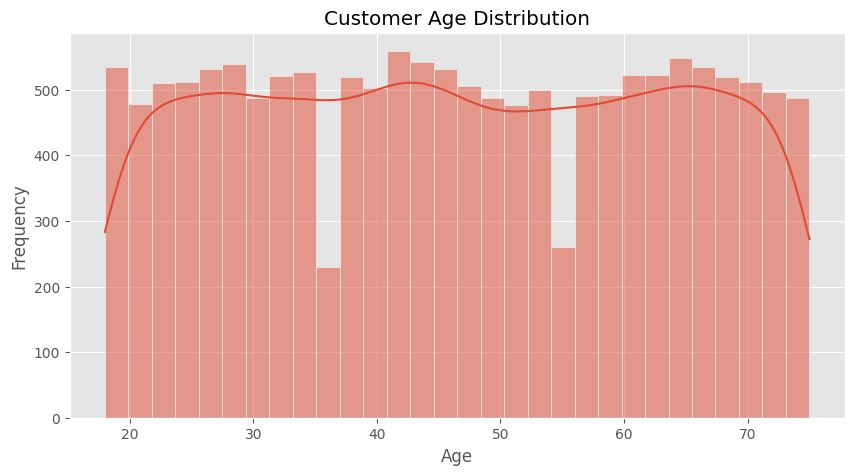

In [40]:
# Customer Demographics Analysis

# Age Distribution
plt.figure(figsize=(10, 5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

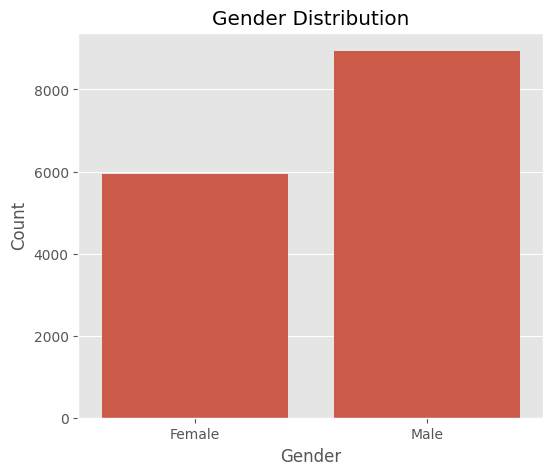

In [41]:
# Gender Distribution
plt.figure(figsize=(6, 5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

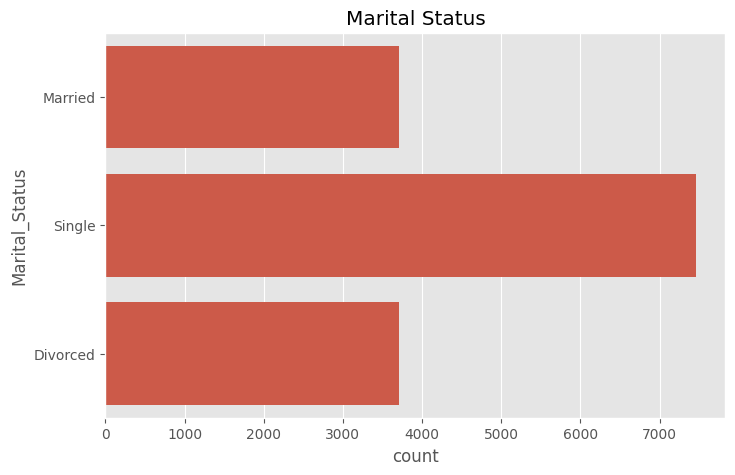

In [42]:
# Marital Status
plt.figure(figsize=(8, 5))

sns.countplot(y="Marital_Status", data=df)

plt.title("Marital Status")

plt.show()

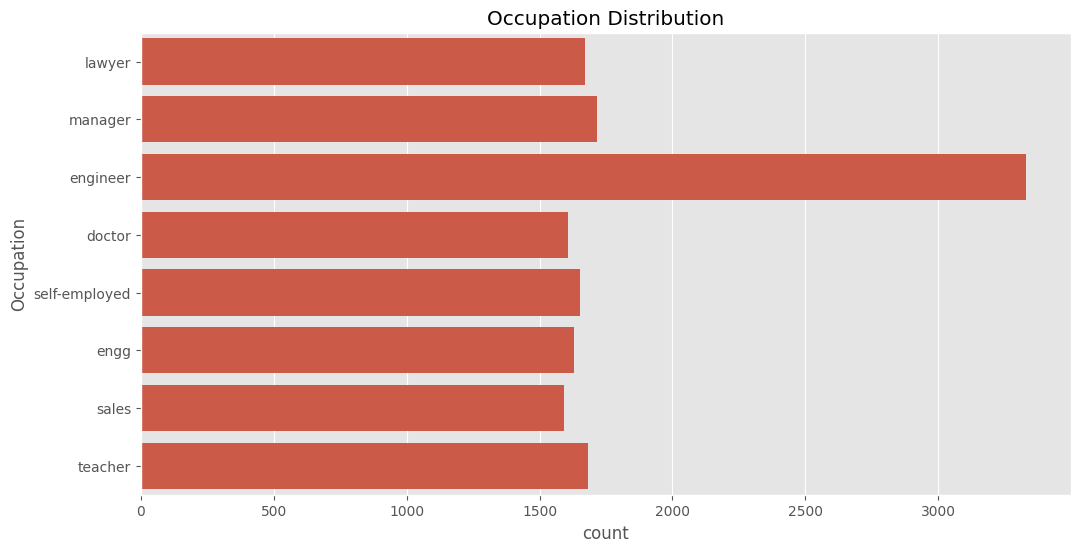

In [43]:
# Occupation Distribution
plt.figure(figsize=(12, 6))

sns.countplot(y="Occupation", data=df)

plt.title("Occupation Distribution")

plt.show()


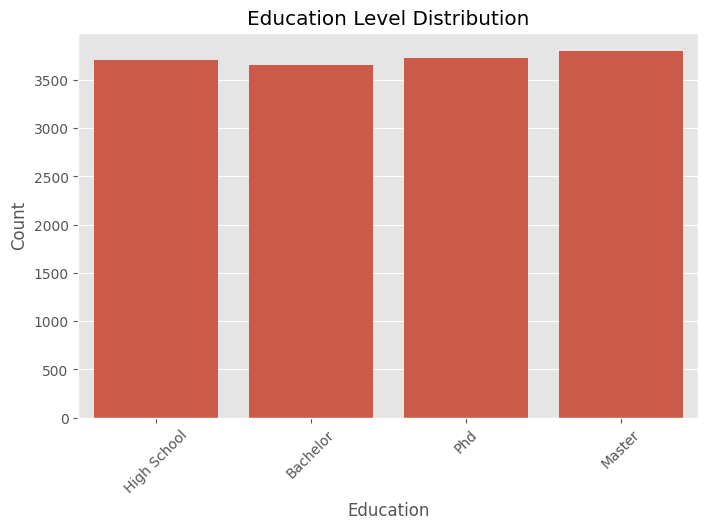

In [44]:
# Education Level
plt.figure(figsize=(8, 5))

sns.countplot(x="Education", data=df)

plt.xticks(rotation=45)
plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

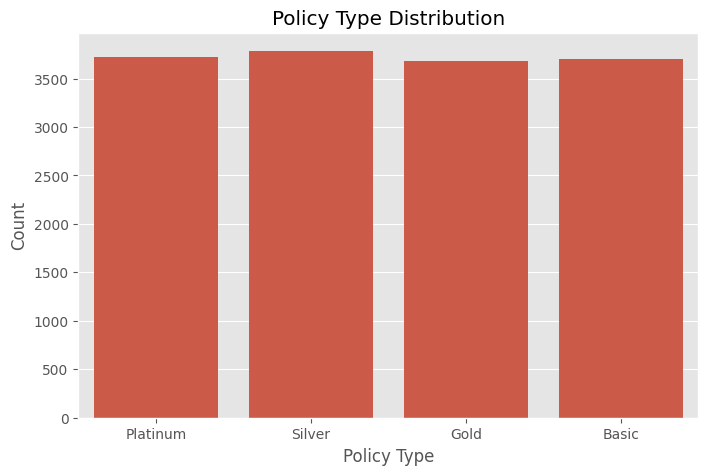

In [45]:
# Policy Type
plt.figure(figsize=(8, 5))

sns.countplot(x="Policy_Type", data=df)

plt.title("Policy Type Distribution")
plt.xlabel("Policy Type")
plt.ylabel("Count")

plt.show()

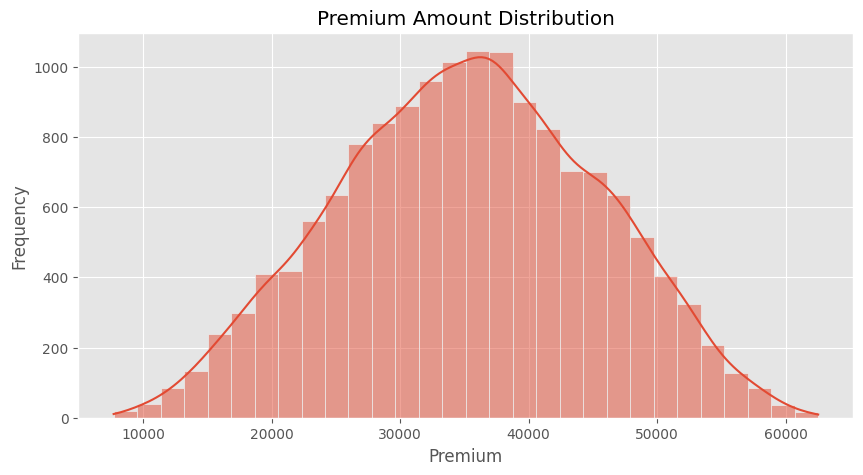

In [46]:
# Premium Amount Distribution
plt.figure(figsize=(10, 5))

sns.histplot(df["Premium"], bins=30, kde=True)

plt.title("Premium Amount Distribution")
plt.xlabel("Premium")
plt.ylabel("Frequency")

plt.show()

In [47]:
# Policy Duration
df["Policy_Duration"] = (
    df["Policy_End_Date"] -
    df["Policy_Start_Date"]
).dt.days

df["Policy_Duration"].describe()

count    1642.000000
mean     1073.660171
std       518.572081
min       365.000000
25%       730.000000
50%      1095.000000
75%      1460.000000
max      1825.000000
Name: Policy_Duration, dtype: float64

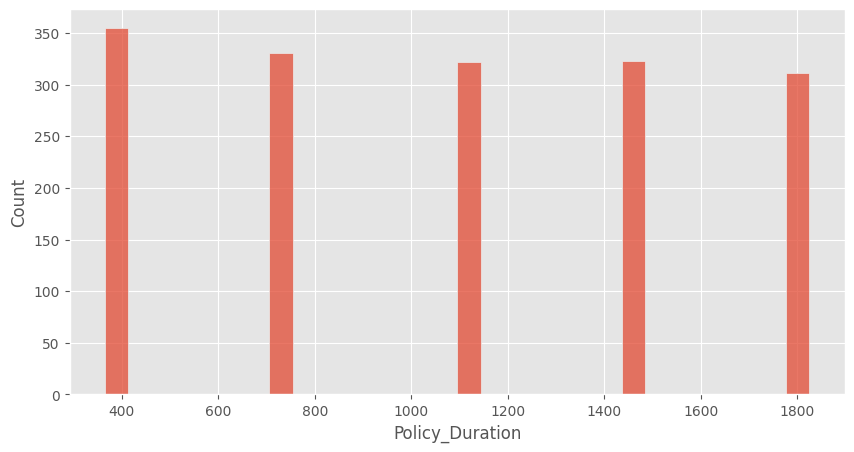

In [48]:
# Policy Duration Distribution

plt.figure(figsize=(10,5))

sns.histplot(df["Policy_Duration"], bins=30)

plt.show()

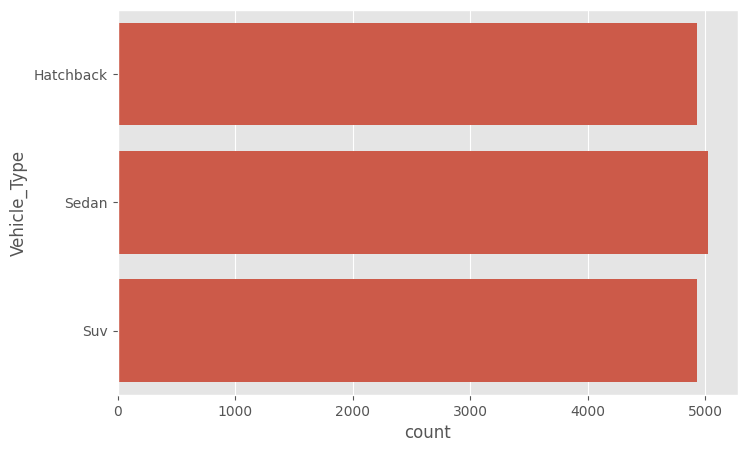

In [49]:
# 3. Vehicle Characteristics

# Vehicle Type
plt.figure(figsize=(8, 5))

sns.countplot(y="Vehicle_Type", data=df)

plt.show()

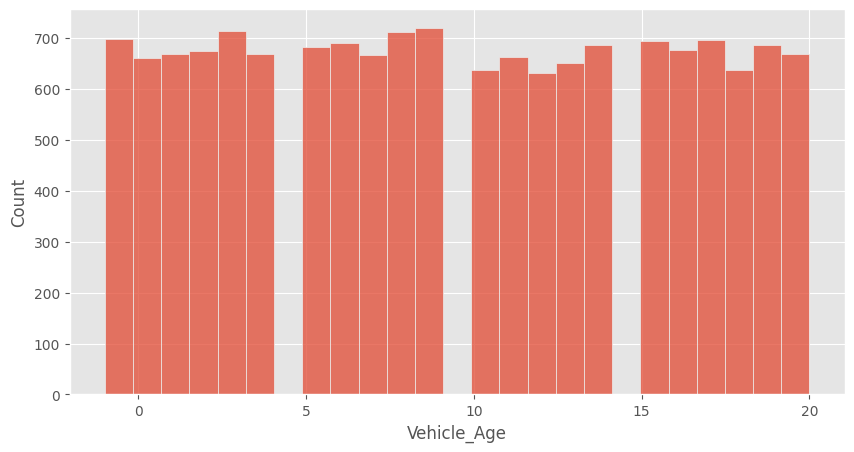

In [50]:
# Vehicle Age Distribution

plt.figure(figsize=(10, 5))

sns.histplot(df["Vehicle_Age"], bins=25)

plt.show()

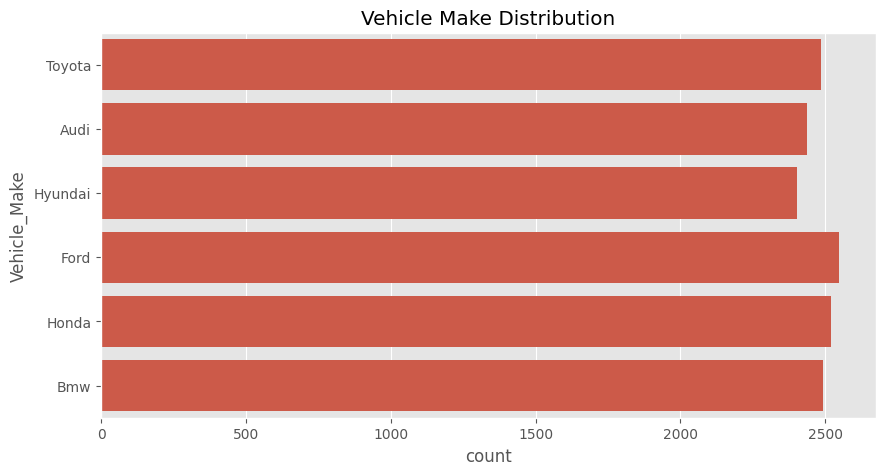

In [51]:
#Vechical Make
plt.figure(figsize=(10,5))
sns.countplot(y="Vehicle_Make", data=df)
plt.title("Vehicle Make Distribution")
plt.show()

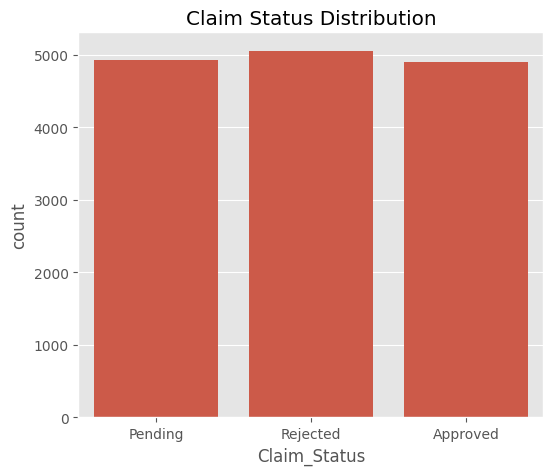

In [52]:
#Claim Status Analysis
plt.figure(figsize=(6,5))
sns.countplot(x="Claim_Status", data=df)
plt.title("Claim Status Distribution")
plt.show()

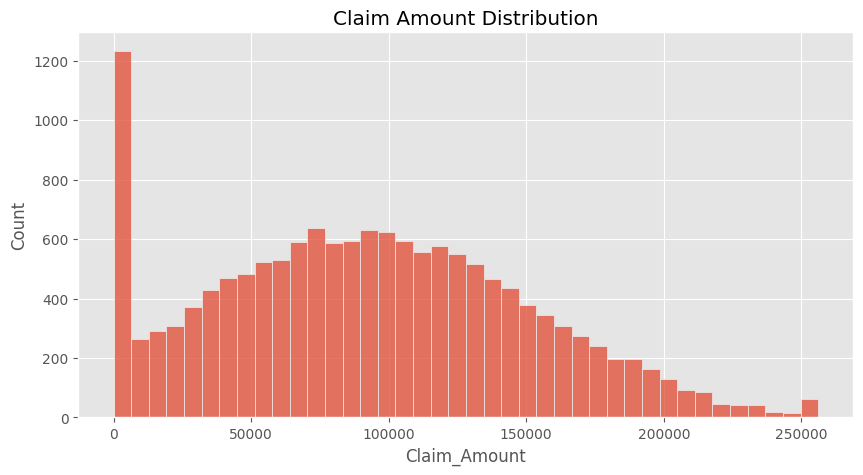

In [53]:
#Claim Amount Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["Claim_Amount"], bins=40)
plt.title("Claim Amount Distribution")
plt.show()

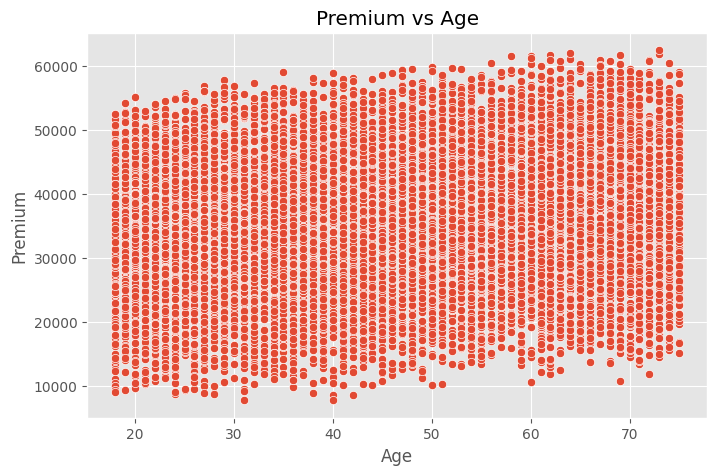

In [54]:
#Premium vs Age
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Premium", data=df)
plt.title("Premium vs Age")
plt.show()

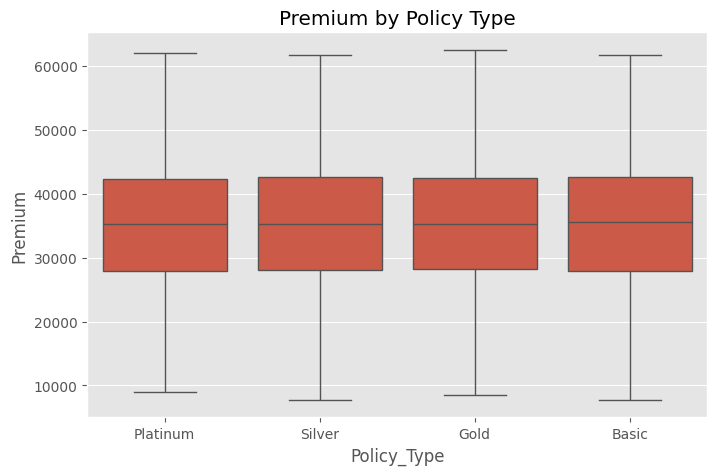

In [55]:
#Premium by Policy Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Policy_Type", y="Premium", data=df)
plt.title("Premium by Policy Type")
plt.show()

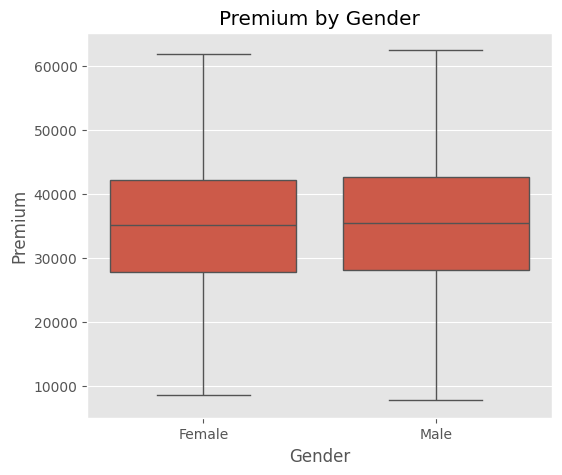

In [56]:
#Premium by Gender
plt.figure(figsize=(6,5))
sns.boxplot(x="Gender", y="Premium", data=df)
plt.title("Premium by Gender")
plt.show()

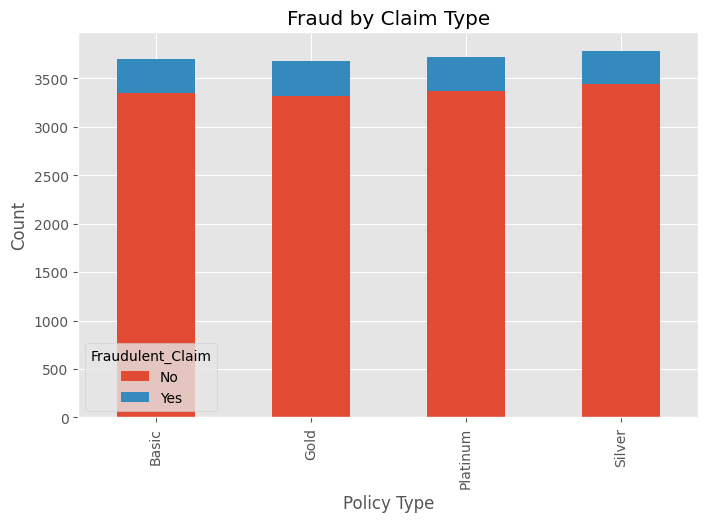

Fraudulent_Claim    No  Yes
Policy_Type                
Basic             3344  354
Gold              3318  364
Platinum          3371  349
Silver            3439  345


In [57]:
fraud_claim = pd.crosstab(df["Policy_Type"],
                          df["Fraudulent_Claim"])

fraud_claim.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Fraud by Claim Type")
plt.xlabel("Policy Type")
plt.ylabel("Count")
plt.show()

print(fraud_claim)

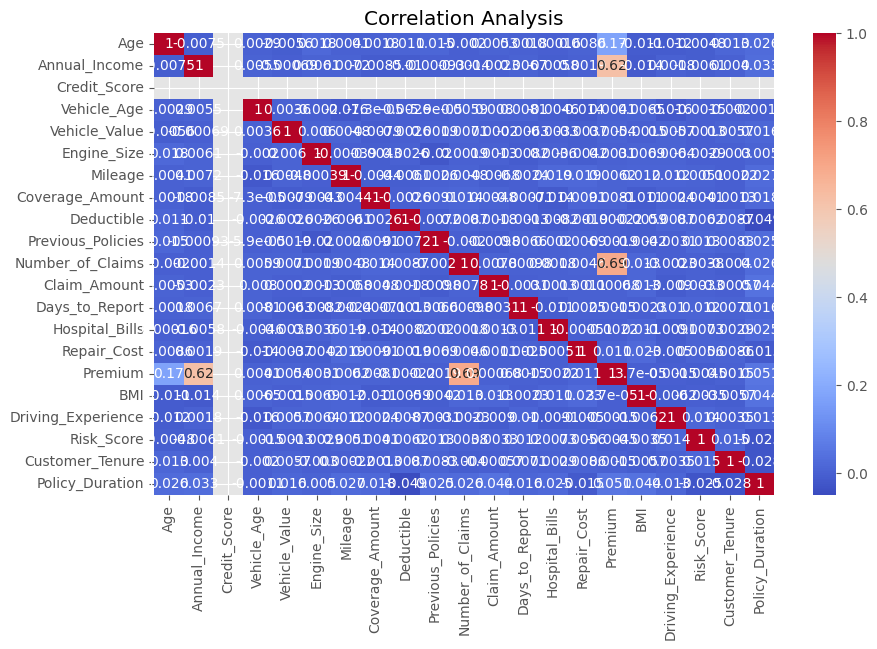

In [58]:
#correlation 
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Analysis")
plt.show()

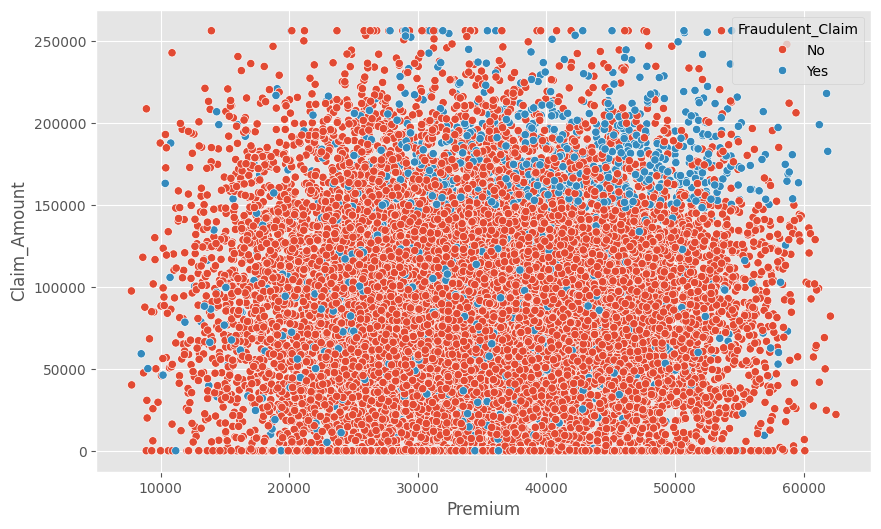

In [59]:
#Premium vs Claim Amount
plt.figure(figsize=(10,6))

sns.scatterplot(x="Premium",
                y="Claim_Amount",
                hue="Fraudulent_Claim",
                data=df)

plt.show()

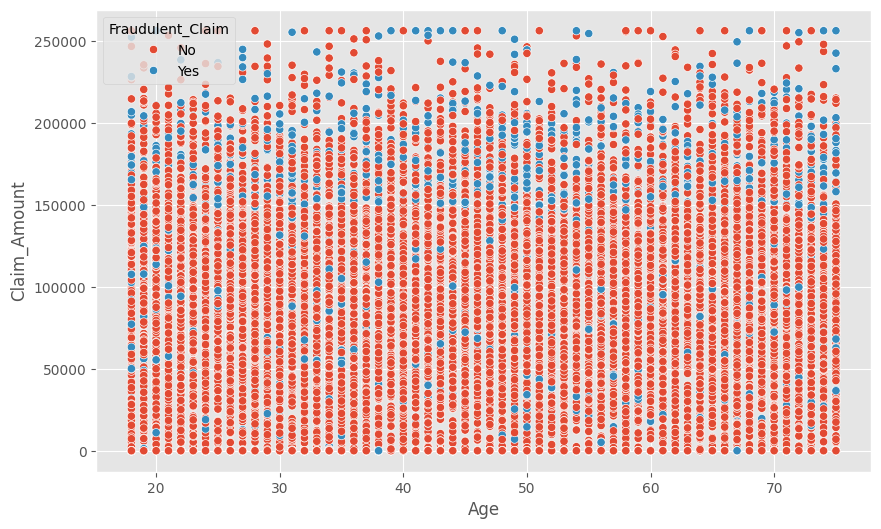

In [60]:
#Age vs Claim Amount
plt.figure(figsize=(10,6))

sns.scatterplot(x="Age",
                y="Claim_Amount",
                hue="Fraudulent_Claim",
                data=df)

plt.show()

In [61]:
#Top 10 Customers by Claim Amount
top_claims = df.nlargest(10, "Claim_Amount")
top_claims[["Customer_ID",
            "Claim_Amount",
            "Policy_Type"]]

,Customer_ID,Claim_Amount,Policy_Type
233,Cust000234,256134.25,Platinum
920,Cust000923,256134.25,Basic
1392,Cust001398,256134.25,Basic
1474,Cust001480,256134.25,Basic
1682,Cust001690,256134.25,Gold
1912,Cust001926,256134.25,Basic
1915,Cust001929,256134.25,Gold
2028,Cust002042,256134.25,Platinum
2670,Cust002691,256134.25,Basic
2710,Cust002731,256134.25,Silver


In [62]:
#Average Premium by Policy Type
df.groupby("Policy_Type")["Premium"]\
.mean()\
.sort_values(ascending=False)

Policy_Type
Silver      35329.465381
Gold        35260.334872
Basic       35252.475122
Platinum    35162.515591
Name: Premium, dtype: float64

In [63]:
#Average Claim by Vehicle Type
df.groupby("Vehicle_Type")["Claim_Amount"]\
.mean()\
.sort_values(ascending=False)

Vehicle_Type
Suv          93139.079260
Sedan        92493.144457
Hatchback    92006.621349
Name: Claim_Amount, dtype: float64

In [64]:
#Fraud Percentage
fraud_rate = round(
    (df["Fraudulent_Claim"].value_counts(normalize=True))*100,
    2
)

fraud_rate

Fraudulent_Claim
No     90.51
Yes     9.49
Name: proportion, dtype: float64

Premium prediction (Regression)

Develop a regression model to predict the annual insurance premium for new customers based on their profile and policy details. • Compare multiple regression algorithms and evaluate their performance.

pandas → Loads and manipulates the dataset. numpy → Performs numerical operations. train_test_split → Splits the data into training and testing sets. LabelEncoder → Converts categorical variables into numbers. StandardScaler → Standardizes numerical features. LinearRegression → Creates the regression model. Metrics → Evaluates the model's performance.

In [65]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [66]:
# Convert Date Columns into Useful Features

date_cols = [
    "Policy_Start_Date",
    "Policy_End_Date",
    "ClaimDate"
]

for col in date_cols:

    if col in df.columns:

        df[col] = pd.to_datetime(df[col])

        df[col + "_Year"] = df[col].dt.year
        df[col + "_Month"] = df[col].dt.month
        df[col + "_Day"] = df[col].dt.day

df.drop(columns=date_cols,inplace=True, errors="ignore")        

Machine Learning needs:
Independent variables (X)
These are the inputs.

Example:
Age
Gender
Vechical Age
occupation
Income
Risk Score
Dependent Variable(y)

this is what we want to predict.
i.e. Premium

In [67]:
# Define Target Variable

# Assume your target column is Premium.

target = "Premium"


In [68]:
# Optional
# Drop Unnecessary Columns

# Drop ID columns that don't contribute to prediction.

drop_cols = [
    "Customer_ID",
    "Policy_ID"
]

drop_cols = [col for col in drop_cols if col in df.columns]

df = df.drop(columns=drop_cols)

Machine learning algorithms cannot understand text.
Example
Before:
Gender Male Female
After encoding:
Gender 1 0
Similarly,
Policy Type Basic Premium
becomes
Policy Type 0 1

In [69]:
#Encode categorical variable
# Encode Categorical Columns

cat_cols = df.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))


In [70]:
# Feature Matrix and Target

X = df.drop(target, axis=1)
y = df[target]

We don't train on the entire dataset.
Instead,
80% → Training
20% → Testing
Example
15000 records
Training
12000
Testing
3000
Testing data is unseen by the model and helps measure how well the model generalizes.

In [71]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Different columns have different scales.
 
Example
 
Age
 
18–70
 
Income
 
50,000–1,000,000
 
Premium
 
10,000–100,000
 
If not scaled,
 
Income dominates Age because of its larger magnitude.
 
StandardScaler transforms features to have:
 
Mean = 0
Standard deviation = 1
 
This often helps linear models perform better.

In [72]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [73]:
# Create Multiple Regression Models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

"Linear Regression": LinearRegression(), Explanation:
Key
"Linear Regression"
This is just a label (name of the model).
Value
LinearRegression()
This creates an object of the Linear Regression algorithm.
Think of it as:
lr_model = LinearRegression()
No training happens yet.
The model is only created.
Later,
lr_model.fit(X_train, y_train)
will train it.
What is Linear Regression?
Linear Regression predicts a continuous value by fitting the best straight-line relationship 
between the features and the target.
It is often used as the baseline model because it is simple, fast, and easy to interpret.

    
"Decision Tree": DecisionTreeRegressor(random_state=42), Explanation
Creates a Decision Tree Regression model.
Decision Trees learn by asking questions such as:
Is Age > 30? | Yes | Income > 600000? | Yes | Premium = 42000
Instead of fitting a straight line, the tree repeatedly splits the data into smaller groups.
Why use it? Captures non-linear relationships. Easy to visualize. Can overfit if not controlled.
    What is random_state=42? random_state=42
Many machine learning algorithms involve randomness.
For example,
Random Forest randomly selects data samples and features.
If you don't specify a random state,
today's result
R² = 0.91
tomorrow's result
R² = 0.89
may differ slightly.
Using
random_state=42
ensures the same random choices are made each time, making your results reproducible.
The number 42 has no special mathematical meaning—it's simply a commonly used fixed seed.


"Random Forest": RandomForestRegressor(random_state=42), Explanation
Creates a Random Forest Regressor.
A Random Forest is made up of many decision trees.
Example:
Tree 1 → 21000
Tree 2 → 22000
Tree 3 → 20500
Tree 4 → 21500
Final Prediction
21250
The final prediction is based on the average prediction from all trees.
Why use it? Usually more accurate than a single decision tree. Reduces overfitting. Handles 
complex patterns well. Line 5 "Gradient Boosting": GradientBoostingRegressor(random_state=42), 
Explanation Gradient Boosting builds trees sequentially.
Instead of creating all trees independently, each new tree focuses on correcting the mistakes 
made by the previous ones.
Example:
Tree 1
Error = 4000
↓
Tree 2 corrects those errors
↓
Tree 3 corrects the remaining errors
↓
Final prediction Why use it? High predictive accuracy. Learns from previous mistakes. Often 
performs very well on structured/tabular data.

    
"Extra Trees": ExtraTreesRegressor(random_state=42), Explanation
Extra Trees (Extremely Randomized Trees) are similar to Random Forest but introduce 
even more randomness.
Random Forest:
Chooses the best split from a random subset of features.
Extra Trees:
Chooses random split points as well, increasing diversity among trees.
    Why use it? Faster training. Reduces overfitting. Often achieves performance comparable 
to or better than Random Forest.


"AdaBoost": AdaBoostRegressor(random_state=42)
Explanation
AdaBoost stands for Adaptive Boosting.
It starts with a simple model and gradually improves by giving more attention to examples that were 
previously predicted poorly.
Example:
Model 1
↓
Find mistakes
↓
Model 2 focuses on those mistakes
↓
Model 3 improves further
↓
Final prediction Why use it? Can improve accuracy over weak learners. 
    Works well on many regression problems. Sensitive to noisy data and outliers. Closing Brace }
This ends the dictionary.
Why store models in a dictionary?
Instead of writing the same training code six times, you can loop over the dictionary.
for name, model in models.items():
Plain Text
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
Here:
name is the dictionary key (e.g., "Linear Regression"). model is the actual model object 
    (e.g., LinearRegression()).
This avoids repetitive code and makes it easy to compare multiple algorithms.
For insurance premium prediction, it's common to start with Linear Regression as a 
baseline because it's easy to interpret. Then compare it with ensemble methods like 
Random Forest, Gradient Boosting, or Extra Trees, which often achieve higher accuracy 
on real-world insurance datasets because they can capture complex, non-linear relationships.

In [74]:
print(X.isnull().sum().sum())

72747


In [75]:
print(X.columns[X.isnull().any()])

print(X.isnull().sum()[X.isnull().sum() > 0])

Index(['Policy_Duration', 'Policy_Start_Date_Year', 'Policy_Start_Date_Month',
       'Policy_Start_Date_Day', 'Policy_End_Date_Year',
       'Policy_End_Date_Month', 'Policy_End_Date_Day'],
      dtype='object')
Policy_Duration            13242
Policy_Start_Date_Year      9908
Policy_Start_Date_Month     9908
Policy_Start_Date_Day       9908
Policy_End_Date_Year        9927
Policy_End_Date_Month       9927
Policy_End_Date_Day         9927
dtype: int64


In [76]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [77]:
print("NaN values in X_train:", X_train.isnull().sum().sum())

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [78]:
print(X.isnull().sum()[X.isnull().sum() > 0])

Policy_Duration            13242
Policy_Start_Date_Year      9908
Policy_Start_Date_Month     9908
Policy_Start_Date_Day       9908
Policy_End_Date_Year        9927
Policy_End_Date_Month       9927
Policy_End_Date_Day         9927
dtype: int64


In [79]:
missing_cols = X.columns[X.isnull().any()]

print(missing_cols)

print(X[missing_cols].isnull().sum())

Index(['Policy_Duration', 'Policy_Start_Date_Year', 'Policy_Start_Date_Month',
       'Policy_Start_Date_Day', 'Policy_End_Date_Year',
       'Policy_End_Date_Month', 'Policy_End_Date_Day'],
      dtype='object')
Policy_Duration            13242
Policy_Start_Date_Year      9908
Policy_Start_Date_Month     9908
Policy_Start_Date_Day       9908
Policy_End_Date_Year        9927
Policy_End_Date_Month       9927
Policy_End_Date_Day         9927
dtype: int64


In [80]:
import pandas as pd
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


Creates an empty Linear Regression model.

No training occurs yet.

The model has not learned anything.

In [83]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](41,)","[ 44.51,1832. , 33.21,..., -22.29, 2.42, 19.81]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.528e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,41
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,40
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](41,)","[131.57,128.27,123.67,..., 88.18, 81.64, 0. ]"


In [84]:
# Train and Evaluate Models

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    MAE = mean_absolute_error(y_test, prediction)

    RMSE = np.sqrt(mean_squared_error(y_test, prediction))

    R2 = r2_score(y_test, prediction)

    results.append([name, MAE, RMSE, R2])

Step 1
results = []
What does it do?

Creates an empty list.

This list will store the performance of each model.

Initially,

results = []

means

No model results are stored yet.

After running all models, it might look like:

results = [
    ["Linear Regression", 1250.5, 1850.2, 0.82],
    ["Decision Tree", 980.3, 1500.8, 0.89],
    ["Random Forest", 850.7, 1320.4, 0.93]
]
**Step 2**
for name, model in models.items():
What is happening?

Remember your dictionary:

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

.items() returns both the key and the value.

Example:

name	model
Linear Regression	LinearRegression()
Decision Tree	DecisionTreeRegressor()
Random Forest	RandomForestRegressor()

The loop runs once for every model.

First iteration
name = "Linear Regression"

model = LinearRegression()
Second iteration
name = "Decision Tree"

model = DecisionTreeRegressor()
Third iteration
name = "Random Forest"

model = RandomForestRegressor()

Instead of writing six separate blocks of code, the loop automatically repeats the same process for each model.

**Step 3**
model.fit(X_train, y_train)
What does fit() mean?

fit() means train the model.

The algorithm studies the training data and learns the relationship between:

Input Features (X_train)

↓

Target (y_train)

Example

Features

Age	Income	Vehicle Age
25	400000	2
35	600000	4
45	900000	6

Target

Premium
12000
18000
26000

The model learns

Age ↑

Income ↑

Vehicle Age ↑

↓

Premium

After fit(), the model has learned the patterns.

**Step 4**
prediction = model.predict(X_test)
What does predict() do?

Now the trained model predicts premiums for customers it has never seen before.

Example

Testing Data

Age	Income	Vehicle Age
30	500000	3
40	700000	5

Predicted Premium

Premium
14500
21500

The predictions are stored in

prediction

Example

prediction

array([14500,21500,18000,22000])
**Step 5**
MAE = mean_absolute_error(y_test, prediction)
What is MAE?

MAE means

Mean Absolute Error

Formula

MAE = Average of |Actual − Predicted|

Example

Actual Premium

Actual	Predicted
10000	11000
15000	14000
20000	20500

Errors

1000

1000

500

Average

(1000 + 1000 + 500)/3

=833.33

So

MAE = 833.33

Smaller MAE means better predictions.

Step 6
RMSE = np.sqrt(mean_squared_error(y_test, prediction))
What happens here?

First

mean_squared_error()

calculates MSE.

Formula

(Actual − Predicted)²

Suppose

Actual

100

Predicted

110

Error

10

Squared Error

100

Large errors become much larger because of squaring.

After computing MSE, you take the square root:

np.sqrt()

This converts the result back to the original unit (premium amount).

RMSE is easier to interpret because it is expressed in the same units as the target variable.

Step 7
R2 = r2_score(y_test, prediction)
What is R² Score?

R² tells us how well the model explains the variation in the target variable.

Interpretation

R²	Meaning
1.00	Perfect prediction
0.95	Excellent
0.90	Very Good
0.80	Good
0.60	Average
0.00	Very Poor

Example

If

R² = 0.92

The model explains 92% of the variation in insurance premiums.

Step 8
results.append([name, MAE, RMSE, R2])
What does append() do?

Adds one row to the results list.

After Linear Regression

results

[
["Linear Regression",850,1200,0.84]
]

After Decision Tree

results

[
["Linear Regression",850,1200,0.84],

["Decision Tree",700,1050,0.89]
]

After Random Forest

results

[
["Linear Regression",850,1200,0.84],

["Decision Tree",700,1050,0.89],

["Random Forest",620,930,0.94]
]

The list keeps growing as each model is evaluated.

Final Output

After all models finish, you convert the list into a DataFrame:

results = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results

In [85]:
# Compare Model Performance

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)
results.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,2043.217757,2368.891516,0.944791
2,Random Forest,2081.401145,2443.713866,0.941248
4,Extra Trees,2221.993235,2697.331635,0.928420
0,Linear Regression,2338.304991,3196.215762,0.899494
1,Decision Tree,2802.978838,3446.321419,0.883149
5,AdaBoost,2845.466546,3490.888835,0.880107


In [86]:
# Best Model

from sklearn.ensemble import GradientBoostingRegressor

best_model = GradientBoostingRegressor(random_state=42)

best_model.fit(X_train, y_train)

prediction = best_model.predict(X_test)

Why is Gradient Boosting the best model?
When comparing regression models, we generally look for:
Highest R² Score (explains more variance in the target) Lowest 
MAE (smallest average prediction error) Lowest RMSE 
(smallest penalty for large prediction errors)

In [90]:
#ACtual vs Predicted
comparsion = pd.DataFrame({
    "Actual Premium" :y_test,
    "Predicted Premium" : prediction
})
comparsion.head(20)

,Actual Premium,Predicted Premium
10937,37176,35495.985834
5219,28348,31098.373572
3745,47219,48902.310538
7639,32097,35692.152840
2301,31698,32756.525836
9255,23722,22232.571140
12340,40041,40202.020227
4561,40427,42413.550268
13879,33139,33467.537390
7195,49074,51606.984663


In [88]:
#feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":best_model.feature_importances_
})

importance = importance.sort_values(
    "Importance", 
    ascending=False)

importance.head(15)

,Feature,Importance
20,Number_of_Claims,0.504698
7,Annual_Income,0.460580
1,Age,0.033686
27,Repair_Cost,0.000147
0,Claim_ID,0.000121
21,Claim_Amount,0.000097
15,Mileage,0.000091
26,Hospital_Bills,0.000083
13,Vehicle_Value,0.000051
30,BMI,0.000048


X contains all the independent variables (features).

Example:

print(X.columns)

Output

Index([ 'Age', 'Gender', 'Vehicle_Age', 'Annual_Income', 'Risk_Score', 'Claim_History', 'Policy_Type', 'Vehicle_Type' ])

These are the variables used to predict the premium.

So,

"Feature": X.columns

creates the first column.

Feature Age Gender Vehicle_Age Annual_Income Risk_Score Claim_History Policy_Type Vehicle_Type Step 3 "Importance": best_model.feature_importances_ What is feature_importances_?

This is a built-in attribute of tree-based models such as:

Decision Tree Random Forest Gradient Boosting Extra Trees

It tells us how important each feature was when making predictions.

Example:

Suppose your model returns

best_model.feature_importances_

Output

[0.12, 0.03, 0.08, 0.25, 0.31, 0.10, 0.07, 0.04]

Each number corresponds to one feature.

Feature Importance Age 0.12 Gender 0.03 Vehicle_Age 0.08 Annual_Income 0.25 Risk_Score 0.31 Claim_History 0.10 Policy_Type 0.07 Vehicle_Type 0.04

Higher importance means the feature had a greater influence on the model's predictions.

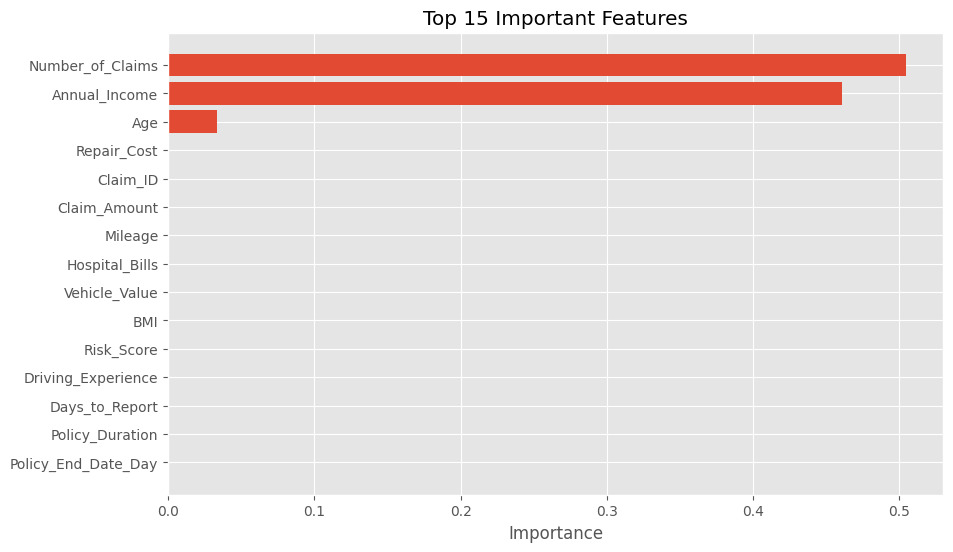

In [89]:
#Plot Feature Importance
import matplotlib.pyplot as plt
 
plt.figure(figsize=(10,6))
 
plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)
 
plt.gca().invert_yaxis()
 
plt.title("Top 15 Important Features")
 
plt.xlabel("Importance")
 
plt.show()

In [91]:
#Predict Premium for New Customer
new_customer = X.iloc[[0]]

predicted_premium = best_model.predict(new_customer)

print("Predicted Annual Premium :", predicted_premium[0])

Predicted Annual Premium : 58158.29184867903


In [92]:
# Save the Model (Optional)

import joblib

joblib.dump(best_model, "Premium_Prediction_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


#Fraud Detection (Classification)
• Build a machine learning model to classify whether an insurance claim is fraudulent. • Identify the key variables contributing to fraud.
Problem Statement
Objective:
Develop a machine learning classification model to predict whether an insurance claim is Fraudulent or Not Fraudulent based on customer details, policy information, vehicle characteristics, and claim history.
Target Variable:
Fraudulent_Claim
Example:
Fraudulent_Claim Meaning 1 Fraudulent Claim
0 Genuine Claim
This is a Binary Classification Problem.

In [93]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [94]:
#Define Target Variable
target = "Fraudulent_Claim"

X = df.drop(target, axis=1)

y = df[target]
#X → Independent variables (customer, policy, vehicle, claim details)

#y → Target variable (Fraudulent_Claim)

In [95]:
#Encode Categorical Variables
encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    
    
    X[col] = encoder.fit_transform(X[col].astype(str))

Why?

Machine Learning cannot understand text.

Example

Before

Gender Male Female

After Encoding

Gender 1 0

Similarly,

Vehicle Type SUV Sedan Truck

becomes

Vehicle Type 2 1 0

Now every categorical column becomes numeric.

In [96]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

We divide data into two parts.

80%

Training Data

↓

20%

Testing Data

Training Data teaches the model.

Testing Data checks how well the model performs on unseen data.

In [97]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [98]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


Different variables have different ranges.

Example

Age

18-70

Income

200000-2500000

Claim Amount

1000-800000

Large numbers dominate smaller ones.

StandardScaler converts every feature to approximately:

Mean = 0

Standard Deviation = 1

This improves the performance of many algorithms.

Note: Scaling is especially useful for Logistic Regression. Tree-based models (Decision Tree, Random Forest, Gradient Boosting, Extra Trees) generally do not require scaling.

In [99]:
# Create Multiple Regression Models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

#Customer Segmentation
•Group customers into different risk categories using clustering techniques.•Recommend targeted pricing and marketing strategies for each customer segment.
    
Customer Segmentation Using Clustering Objective
Group customers into different risk categories and recommend pricing and
marketing strategies for each segment.
Features to Use
Select customer attributes that indicate insurance risk, such as:
Age Annual_Income Credit_Score Vehicle_Age Vehicle_Value Number_of_Claims 
Claim_Amount Driving_Experience Mileage BMI Risk_Score Customer_Tenure

In [100]:
# Prepare the Data
from sklearn.preprocessing import StandardScaler

features = [
    'Age',
    'Annual_Income',
    'Credit_Score',
    'Vehicle_Age',
    'Vehicle_Value',
    'Number_of_Claims',
    'Claim_Amount',
    'Driving_Experience',
    'Mileage',
    'BMI',
    'Risk_Score',
    'Customer_Tenure'
]

X = df[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Why is scaling needed?
K-Means uses distance calculations (Euclidean distance).
Suppose:
Income = 1,000,000
large number
Credit Score = 700
smaller number
Without scaling, income would dominate the distance calculation and the algorithm would ignore other features.
What StandardScaler does
It converts every feature to a common scale:
Standardized value
(value − mean) / standard deviation Result
Each column will have:
Mean ≈ 0
Standard deviation ≈ 1
This ensures all features contribute fairly.

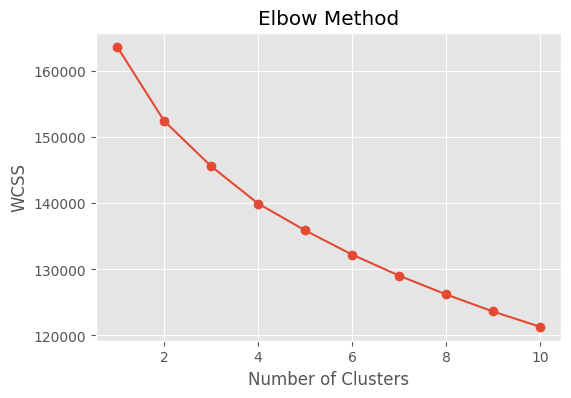

In [102]:
# Find the Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

What is WCSS?

WCSS = Within Cluster Sum of Squares

It measures how close the points are to their cluster center.

Lower WCSS = better clustering

How the loop works

k Meaning

1

Put all customers in one cluster 2

Split into two clusters

3

Split into three clusters

… Continue up to 10 Find the point where the curve bends like an elbow.

That is usually the optimal number of clusters.

In many insurance datasets, k = 3 works well (Low, Medium, High Risk).



In [103]:
# Train the K-Means Model
# Model training

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Customer_Segment'] = kmeans.fit_predict(X_scaled)

What happens internally?

The algorithm randomly places 3 centroids.

Each customer is assigned to the nearest centroid.

Centroids are recalculated.

The process repeats until the clusters stabilize.

Output:

A new column is created:

Customer

Customer_Segment

A

0

B

2

C

1

The numbers are just labels; we still need to interpret them.

In [104]:
# Understand Each Cluster

segment_summary = df.groupby('Customer_Segment')[features].mean()
segment_summary

,Age,Annual_Income,Credit_Score,Vehicle_Age,Vehicle_Value,Number_of_Claims,Claim_Amount,Driving_Experience,Mileage,BMI,Risk_Score,Customer_Tenure
Customer_Segment,,,,,,,,,,,,
0,29.122801,1.650900e+06,648.0,9.117594,1.590238e+06,2.956014,88204.077379,21.523160,130953.827110,29.088636,52.087612,7.278097
1,55.131405,1.626734e+06,648.0,9.945661,1.539366e+06,2.961364,95570.163481,8.594628,116100.773140,28.902789,48.191116,7.717975
2,58.586947,1.599684e+06,648.0,9.368797,1.600727e+06,3.107510,94679.830018,30.436299,132099.649084,29.010818,51.012517,7.441663


What this does

Calculates the average value of every feature for each cluster.

Example output

Feature

Cluster 0

Cluster 1

Cluster 2

Claims

0.5

1.8

3.9

Credit Score

780

690

590

Risk Score

18

45

82

Interpretation

Cluster 0

Low Risk

Few claims • High credit score • Low risk score

Cluster 1

Medium Risk

Moderate claims • Average credit score • Medium risk score

Cluster 2

High Risk

Many claims • Low credit score • High risk score

In [105]:
#Rename Segments
segment_map = {
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
}

df['Risk_Category'] = df['Customer_Segment'].map(segment_map)

Pricing Strategy

Segment

Recommended Pricing

Low Risk

10–15% discount, loyalty rewards

Medium Risk

Standard premium, safe-driving incentives

High Risk

Higher premium, larger deductible

Marketing Strategy

Segment

Marketing Focus

Low Risk

Premium plans, family bundles

Medium Risk

Personalized discounts, renewal reminders

High Risk

Telematics, defensive driving programs

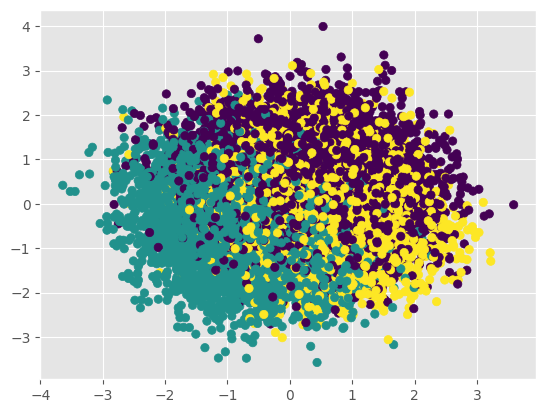

In [106]:
# Visualize the Clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:, 0],X_pca[:, 1],
    c=df['Customer_Segment'],
    cmap='viridis'
)

plt.show()

#Final Business Interpretation Project Conclusion

Using K-Means clustering, customers were segmented into Low, Medium, and High Risk groups based on demographic, financial, vehicle, and claims-related attributes.

Key findings:

Low Risk customers have high credit scores, fewer claims, and lower risk scores.

Medium Risk customers show moderate claim frequency and average financial characteristics.

High Risk customers have higher claim counts, larger claim amounts, and lower credit scores.

Business impact:

Enables risk-based premium pricing.

Improves underwriting decisions.

Supports targeted marketing campaigns.

Helps increase profitability while improving customer retention.

Business Dashboard • Design an interactive dashboard to monitor key performance indicators (KPIs), claim trends, premium distribution, customer segments, and fraud statistics.

Observation

The fraud detection model identified customers and claims with a higher probability of being fraudulent. Fraudulent claims increase operational costs and reduce company profits.

Recommendations Use the trained fraud detection model to automatically flag high-risk claims for manual review. Verify supporting documents before approving high-value claims. Implement real-time fraud monitoring using machine learning models. Regularly update fraud detection models with new claim data to improve accuracy. Investigate customers with repeated suspicious claims or unusually high claim amounts. Business Impact Reduces financial losses due to fraudulent claims. Speeds up claim processing for genuine customers. Improves operational efficiency.

Optimize Premium Pricing Observation

Customer segmentation identified Low, Medium, and High Risk customers based on their claim history, risk score, driving experience, and financial profile.

Recommendations Offer lower premiums to low-risk customers to encourage policy renewals. Maintain standard premiums for medium-risk customers. Charge higher premiums or deductibles for high-risk customers. Introduce usage-based insurance using telematics for fair premium calculation. Review premium pricing annually based on updated customer risk scores. Business Impact Ensures fair pricing based on customer risk. Reduces losses from underpriced high-risk policies. Improves competitiveness by rewarding safe customers.

Improve Customer Retention

Low-risk customers contribute stable premium income with fewer claims, making them valuable long-term customers.

Recommendations:- Introduce loyalty rewards for long-term policyholders. Offer premium discounts for claim-free years. Provide personalized renewal reminders and policy recommendations. Offer bundled insurance products (vehicle, health, and home insurance). Improve customer service through faster claim settlement.

Business Impact Increases customer satisfaction. Reduces customer churn. Improves long-term revenue.

Increase Profitability Claim costs and fraudulent claims significantly impact overall profitability.

Recommendations:- Focus marketing campaigns on acquiring low-risk customers. Reduce claim processing costs through automation. Improve fraud detection to minimize unnecessary claim payouts. Use predictive analytics to identify customers likely to file high-cost claims. Continuously monitor business KPIs through an interactive dashboard.

Business Impact Increases profit margins. Reduces operational expenses. Improves overall financial performance.


